STEP 1: IMPORTING LIBRARIES
✅ All libraries imported successfully!

STEP 2: LOADING DATASET
✅ Dataset loaded successfully!
📊 Dataset shape: 375 rows × 6 columns

STEP 3: EXPLORATORY DATA ANALYSIS (EDA)

📋 First 5 rows of the dataset:
    Age  Gender Education Level          Job Title  Years of Experience  \
0  32.0    Male      Bachelor's  Software Engineer                  5.0   
1  28.0  Female        Master's       Data Analyst                  3.0   
2  45.0    Male             PhD     Senior Manager                 15.0   
3  36.0  Female      Bachelor's    Sales Associate                  7.0   
4  52.0    Male        Master's           Director                 20.0   

     Salary  
0   90000.0  
1   65000.0  
2  150000.0  
3   60000.0  
4  200000.0  

📊 Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0 

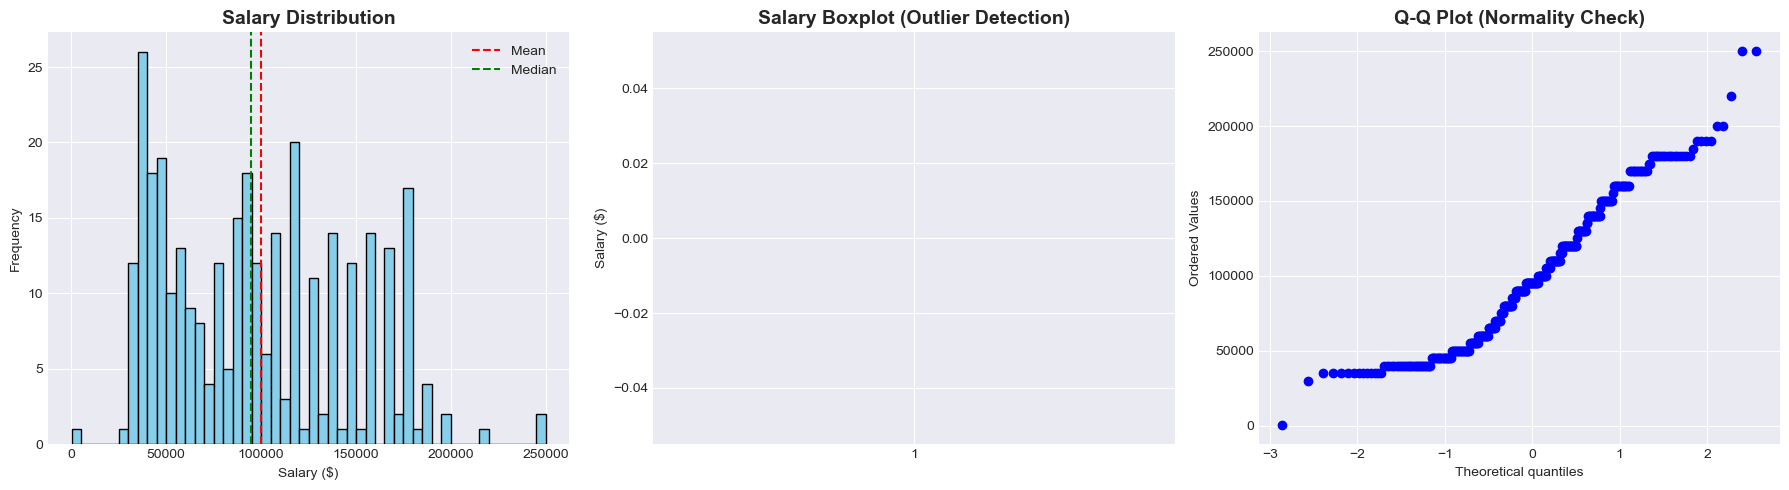


💰 Salary Statistics:
   Mean: $99,985.65
   Median: $95,000.00
   Std Dev: $48,652.27
   Min: $350.00
   Max: $250,000.00

STEP 5: ANALYZING FEATURES


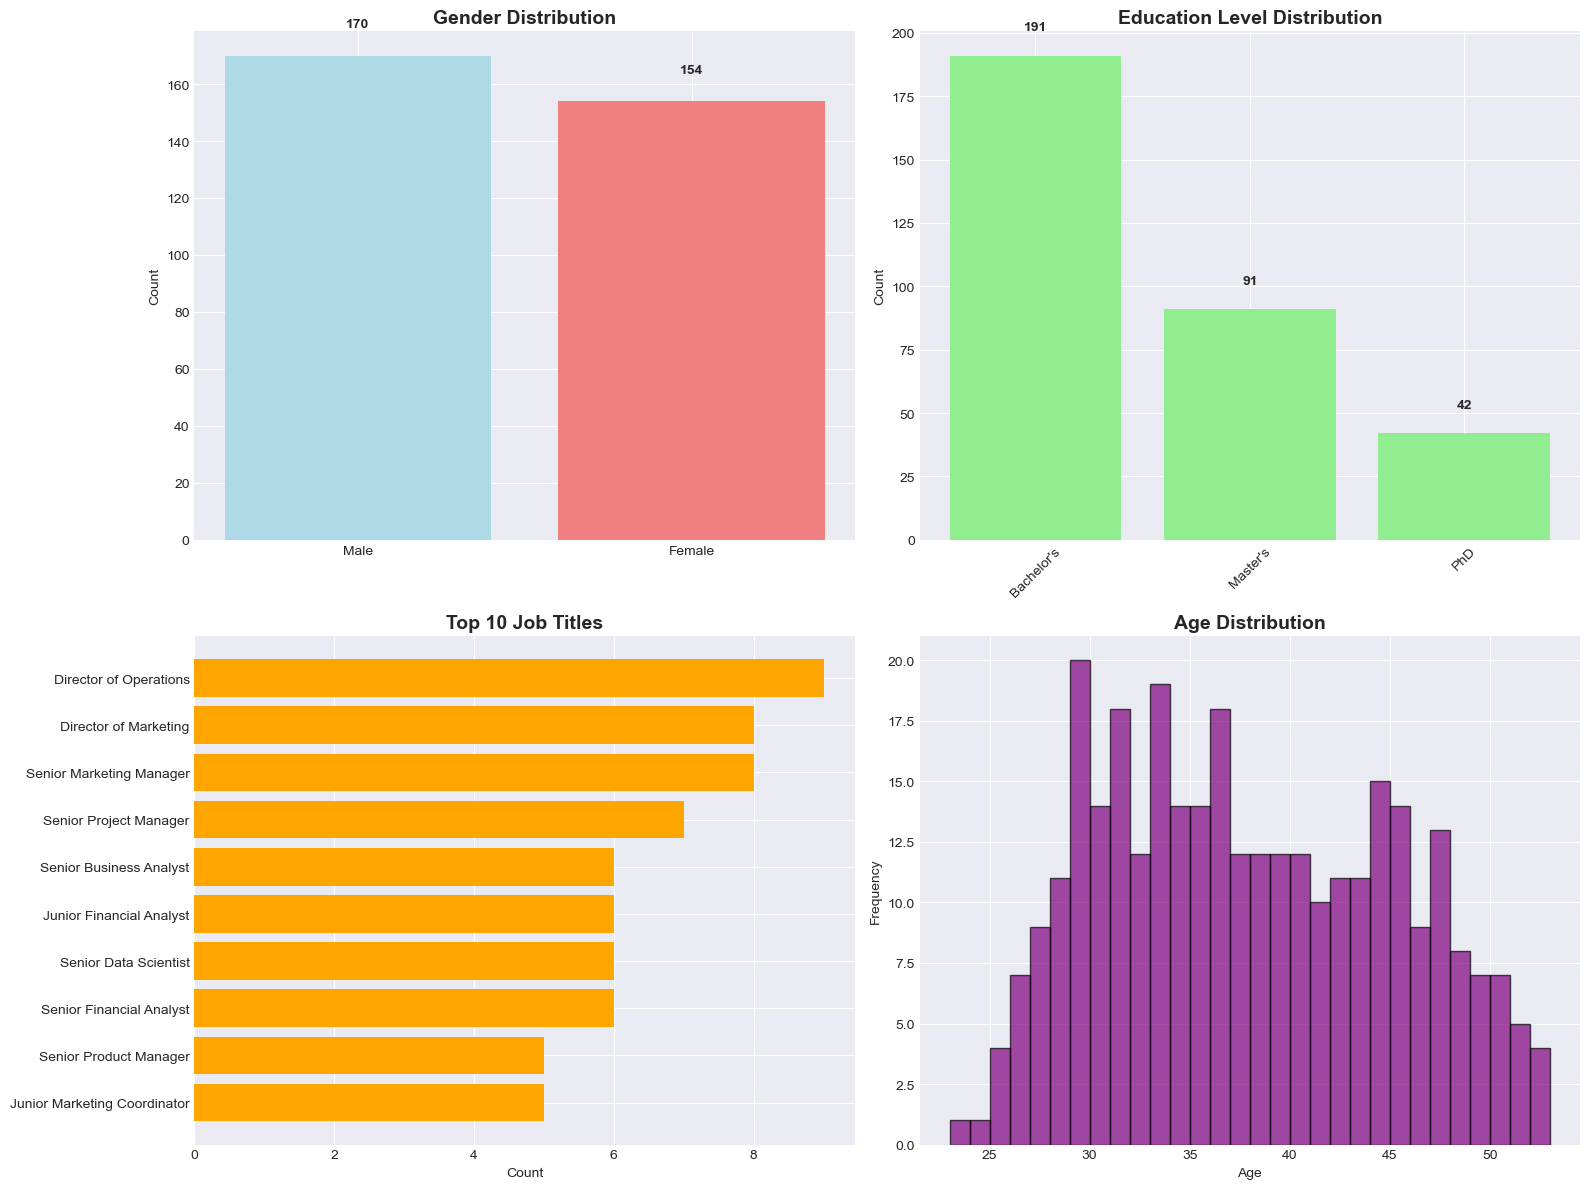


📊 Categorical Features Summary:
   Unique Genders: 2
   Unique Education Levels: 3
   Unique Job Titles: 174

STEP 6: CORRELATION ANALYSIS


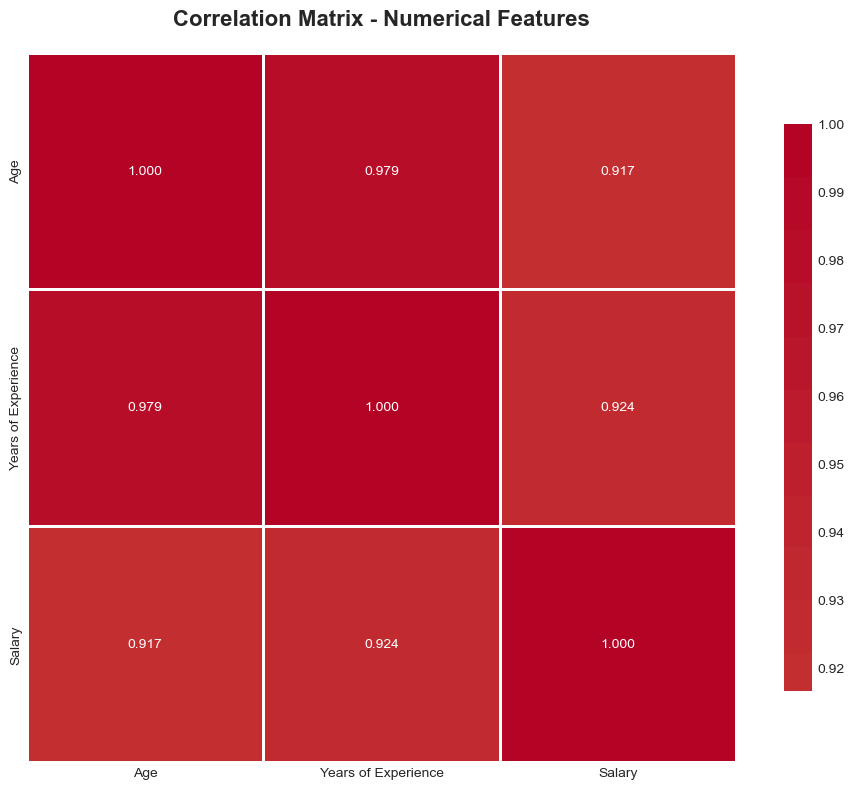


🔗 Key Correlations with Salary:
   Years of Experience: 0.924
   Age: 0.917

STEP 7: VISUALIZING RELATIONSHIPS WITH SALARY


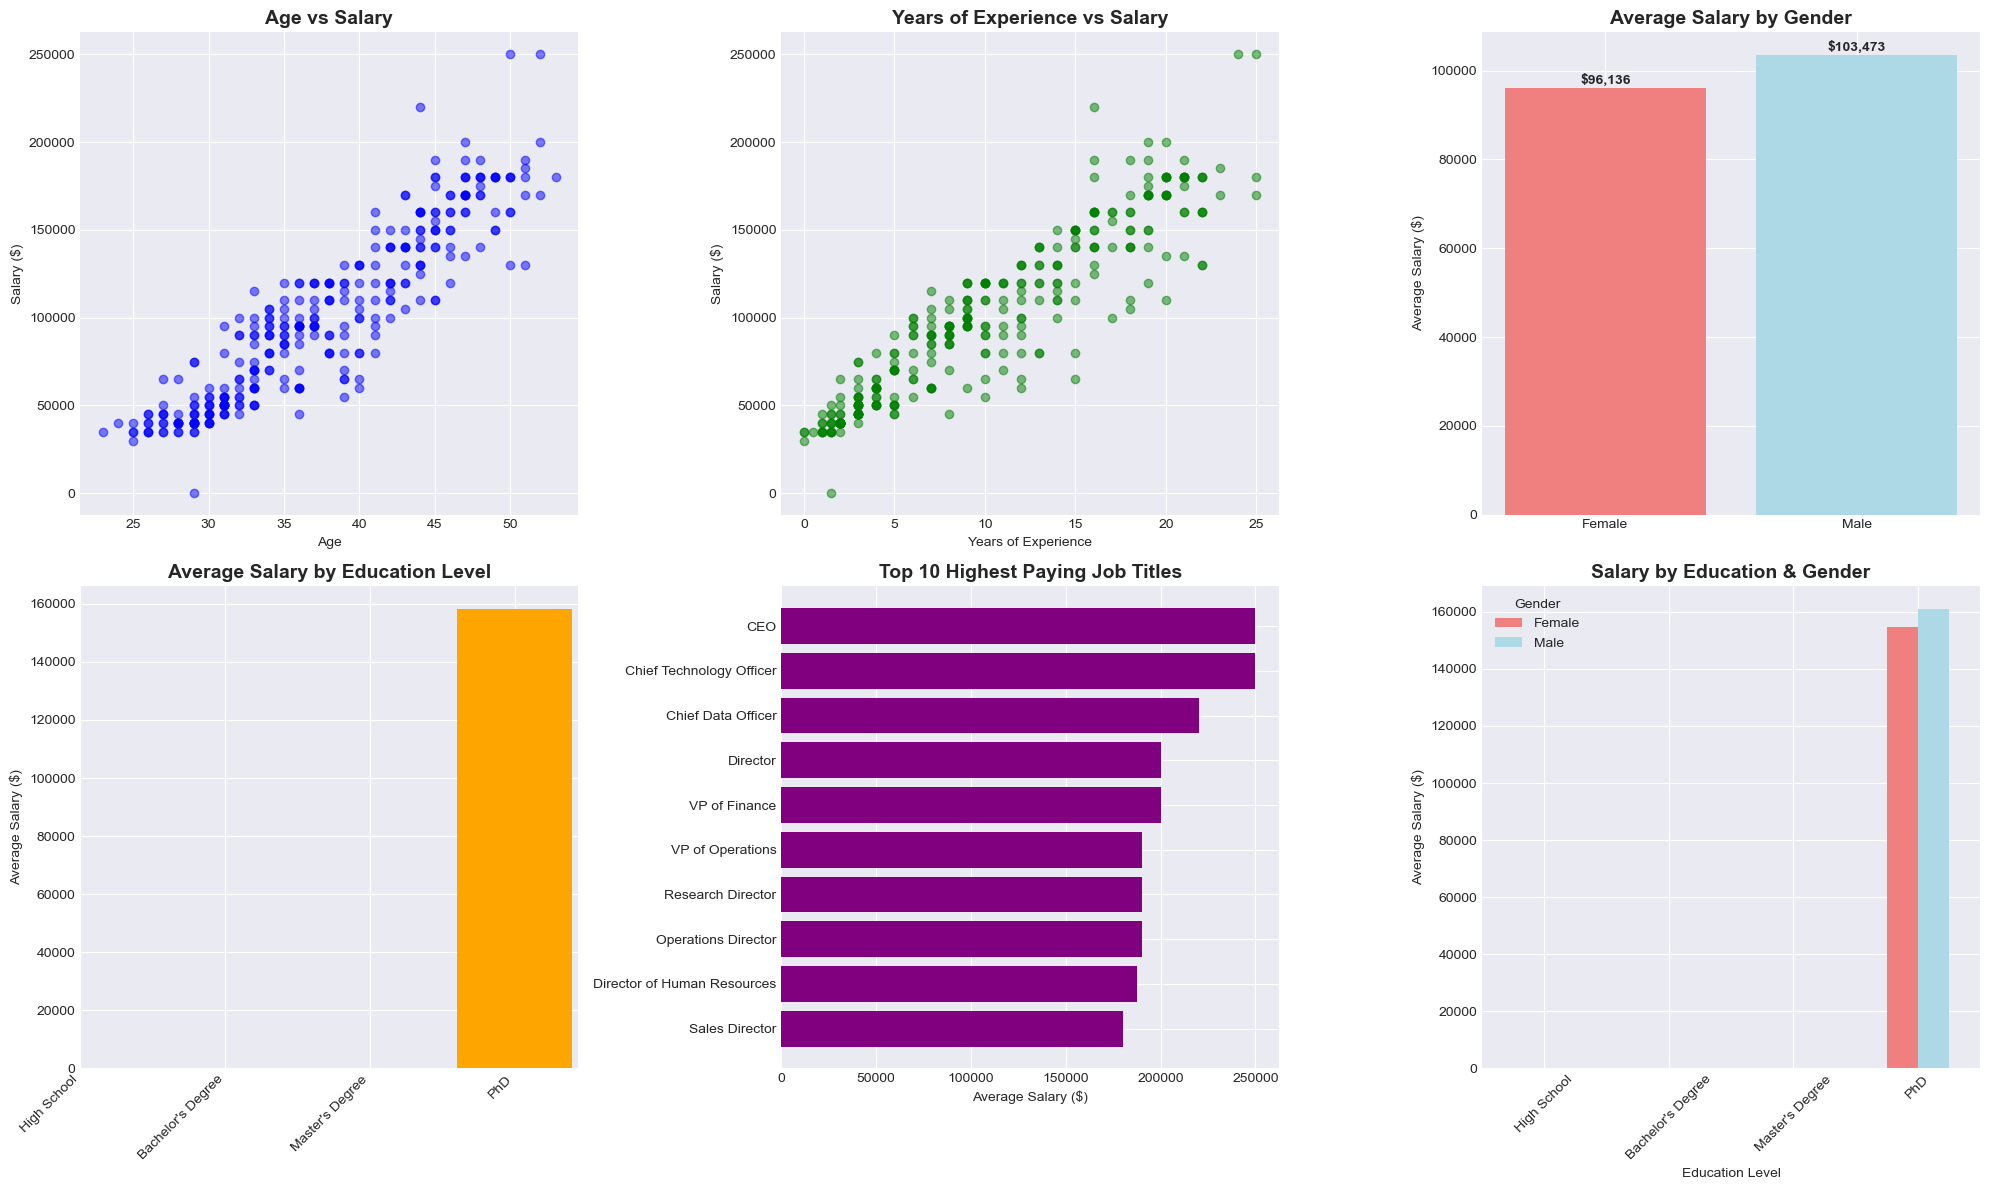

✅ Relationship visualizations created!

STEP 8: OUTLIER DETECTION

🔍 Age:
   Outliers found: 0
   Valid range: [11.50, 63.50]

🔍 Years of Experience:
   Outliers found: 0
   Valid range: [-14.00, 34.00]

🔍 Salary:
   Outliers found: 0
   Valid range: [-72500.00, 267500.00]


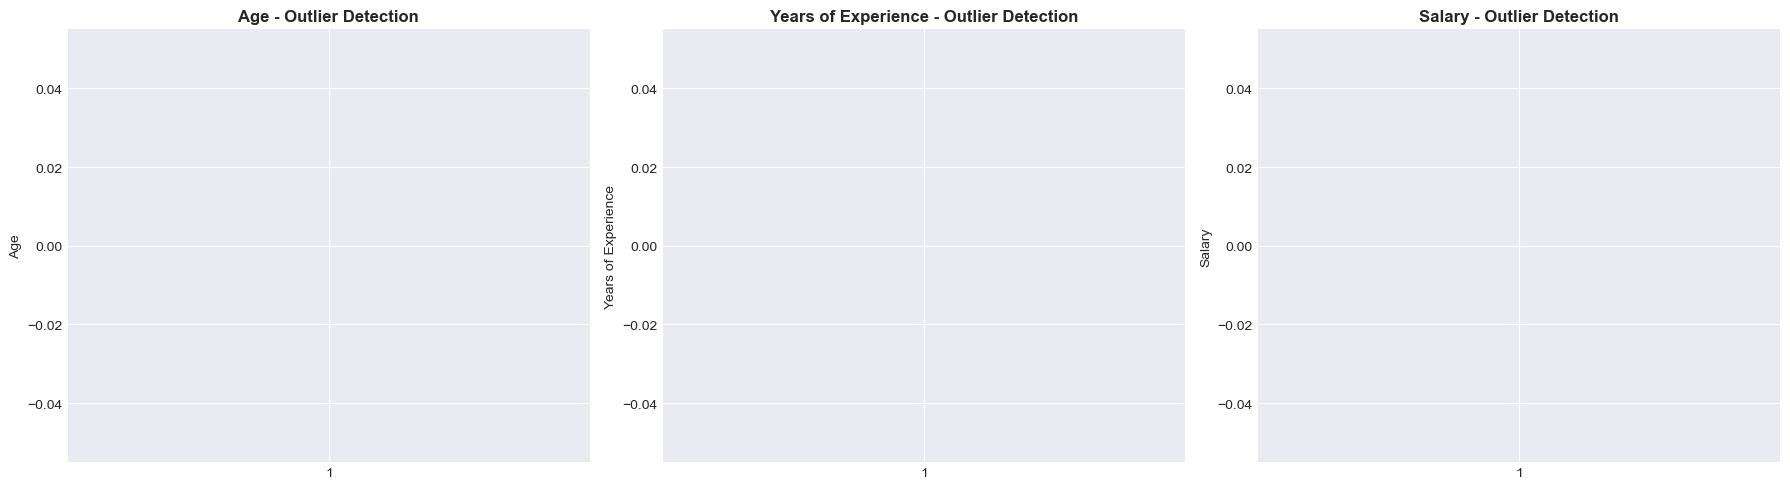


STEP 9: DATA PREPROCESSING

🔧 Handling Missing Values...
Missing values before handling: 6
✅ Missing values after handling: 0

🔍 Checking Education Level unique values:
["Bachelor's" "Master's" 'PhD']

🔄 Encoding Gender...
✅ Gender encoded: Male=1, Female=0

🔄 Encoding Education Level...
Found education levels: ["Bachelor's" "Master's" 'PhD']
✅ Education Level encoded successfully

🔄 Encoding Job Title...
✅ Job Title encoded using target encoding (mean salary)

🔨 Creating new features...
✅ Created features: Experience_Age_Ratio, Education_Experience

🔍 Final comprehensive NaN check:
Series([], dtype: int64)
✅ No NaN values found!

📊 Processed Dataset Sample:
    Age  Gender  Education Level  Job_Title_Encoded  Years of Experience  \
0  32.0       1                1       90000.000000                  5.0   
1  28.0       0                2       72500.000000                  3.0   
2  45.0       1                3      160000.000000                 15.0   
3  36.0       0             

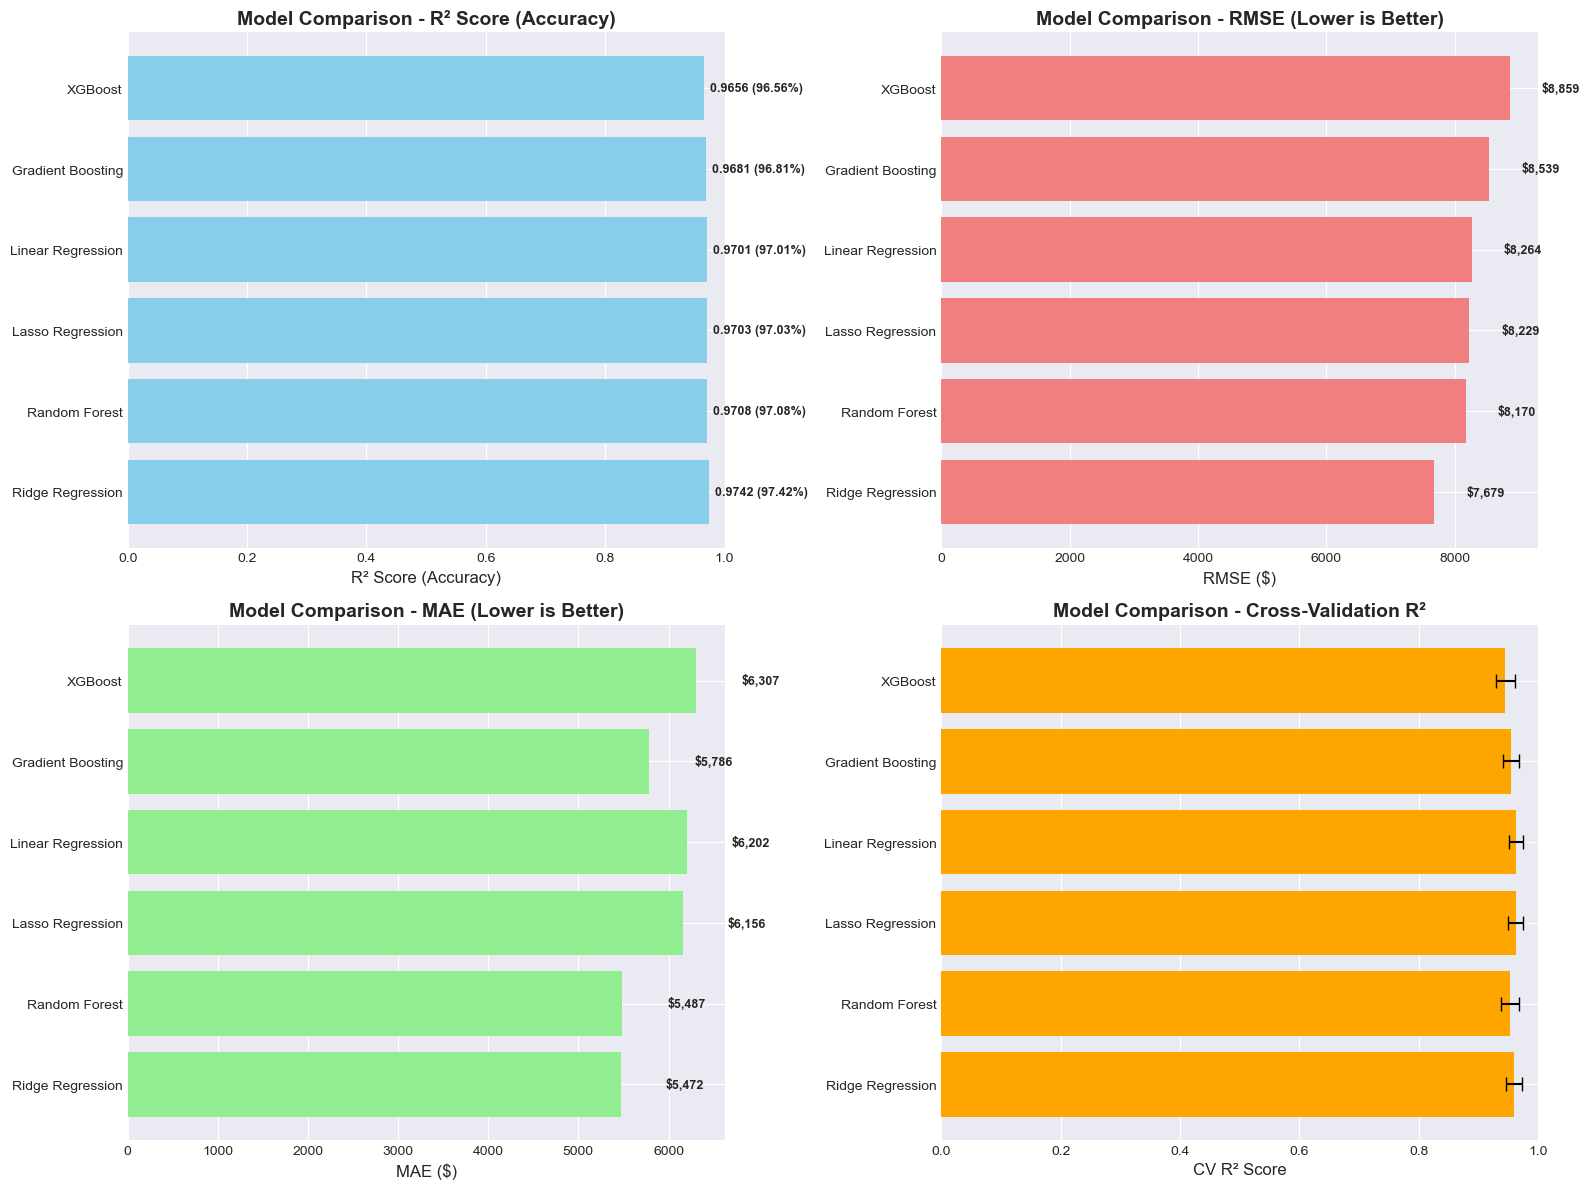


STEP 13: BEST MODEL ANALYSIS

🏆 BEST MODEL: Ridge Regression
   R² Score: 0.9742
   RMSE: $7,679.27
   MAE: $5,472.04

STEP 14: PREDICTION VISUALIZATION


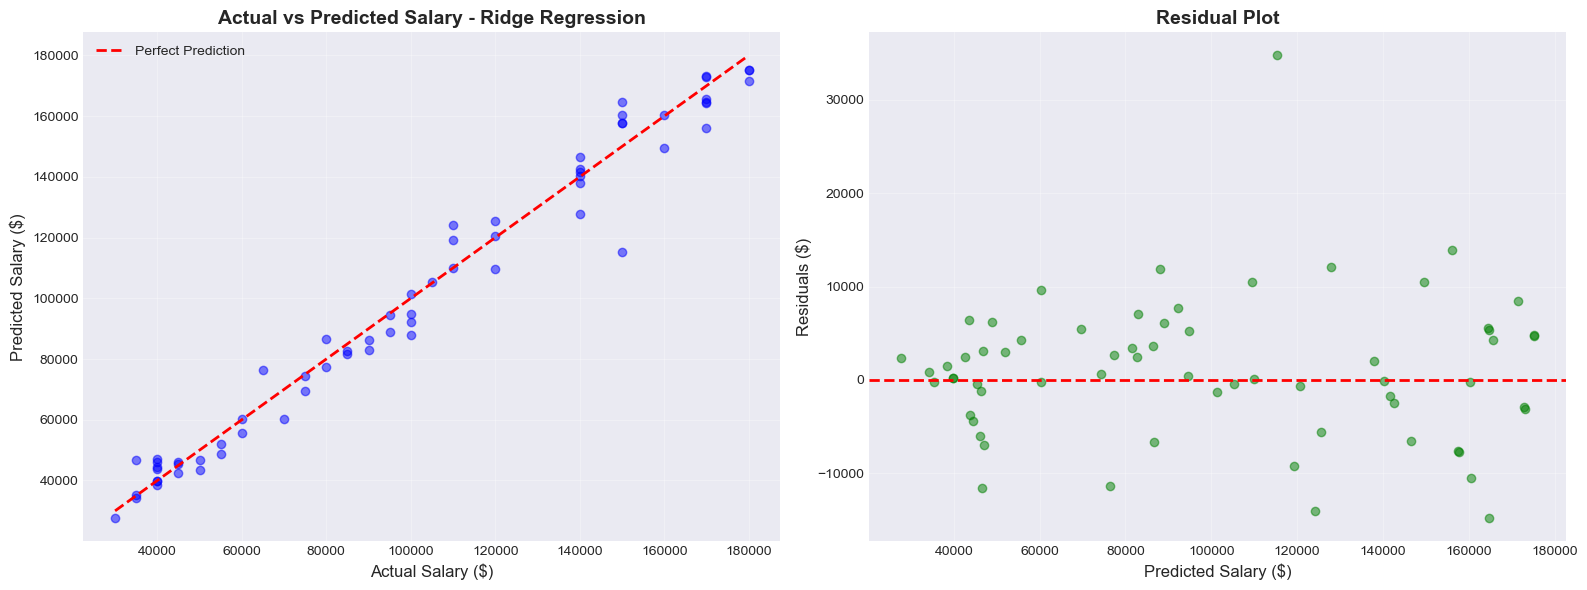


STEP 15: SAMPLE PREDICTIONS

📋 Sample Predictions (First 10):
 Actual Salary  Predicted Salary    Difference   Error %
       45000.0      46229.321631  -1229.321631  2.731826
      110000.0     119247.702419  -9247.702419  8.407002
      170000.0     165762.503814   4237.496186  2.492645
      110000.0     124089.040061 -14089.040061 12.808218
      170000.0     156094.029306  13905.970694  8.179983
      170000.0     173162.389241  -3162.389241  1.860229
       55000.0      51988.561604   3011.438396  5.475343
      110000.0     109856.464837    143.535163  0.130487
       90000.0      82933.453590   7066.546410  7.851718
       95000.0      94545.552060    454.447940  0.478366

📊 Average Prediction Error: 5.04%

STEP 16: SAVING MODELS FOR STREAMLIT DEPLOYMENT
✅ Created 'models' directory

💾 Saving all models...
   ✅ Saved: Linear Regression → models/linear_regression.pkl
   ✅ Saved: Ridge Regression → models/ridge_regression.pkl
   ✅ Saved: Lasso Regression → models/lasso_regressio

In [1]:
# ============================================================================
# SALARY PREDICTION - COMPLETE DATA SCIENCE PIPELINE
# ============================================================================
# Dataset: Salary Prediction for Beginners
# Goal: Predict employee salaries based on demographic and job features
# Author: Your Data Science Assistant
# ============================================================================

# ============================================================================
# STEP 1: IMPORT LIBRARIES
# ============================================================================
print("="*80)
print("STEP 1: IMPORTING LIBRARIES")
print("="*80)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Machine Learning Libraries
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from xgboost import XGBRegressor

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ All libraries imported successfully!\n")

# ============================================================================
# STEP 2: LOAD DATA
# ============================================================================
print("="*80)
print("STEP 2: LOADING DATASET")
print("="*80)

# Note: Replace 'Salary_Data.csv' with your actual file path
# Download from: https://www.kaggle.com/datasets/rkiattisak/salaly-prediction-for-beginer
df = pd.read_csv('Salary Data.csv')

print(f"✅ Dataset loaded successfully!")
print(f"📊 Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns\n")

# ============================================================================
# STEP 3: EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================================
print("="*80)
print("STEP 3: EXPLORATORY DATA ANALYSIS (EDA)")
print("="*80)

# 3.1: Display first rows
print("\n📋 First 5 rows of the dataset:")
print(df.head())

# 3.2: Dataset info
print("\n📊 Dataset Information:")
print(df.info())

# 3.3: Statistical summary
print("\n📈 Statistical Summary:")
print(df.describe())

# 3.4: Check for missing values
print("\n🔍 Missing Values Check:")
missing = df.isnull().sum()
print(missing)
if missing.sum() == 0:
    print("✅ No missing values found!")

# 3.5: Check for duplicates
duplicates = df.duplicated().sum()
print(f"\n🔍 Duplicate rows: {duplicates}")
if duplicates > 0:
    df = df.drop_duplicates()
    print(f"✅ Removed {duplicates} duplicate rows")

# ============================================================================
# STEP 4: DATA VISUALIZATION - PART 1 (Target Variable)
# ============================================================================
print("\n" + "="*80)
print("STEP 4: VISUALIZING TARGET VARIABLE (SALARY)")
print("="*80)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Salary distribution
axes[0].hist(df['Salary'], bins=50, color='skyblue', edgecolor='black')
axes[0].set_title('Salary Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Salary ($)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['Salary'].mean(), color='red', linestyle='--', label='Mean')
axes[0].axvline(df['Salary'].median(), color='green', linestyle='--', label='Median')
axes[0].legend()

# Box plot
axes[1].boxplot(df['Salary'], vert=True)
axes[1].set_title('Salary Boxplot (Outlier Detection)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Salary ($)')

# Q-Q plot for normality check
from scipy import stats
stats.probplot(df['Salary'], dist="norm", plot=axes[2])
axes[2].set_title('Q-Q Plot (Normality Check)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('01_salary_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n💰 Salary Statistics:")
print(f"   Mean: ${df['Salary'].mean():,.2f}")
print(f"   Median: ${df['Salary'].median():,.2f}")
print(f"   Std Dev: ${df['Salary'].std():,.2f}")
print(f"   Min: ${df['Salary'].min():,.2f}")
print(f"   Max: ${df['Salary'].max():,.2f}")

# ============================================================================
# STEP 5: DATA VISUALIZATION - PART 2 (Feature Analysis)
# ============================================================================
print("\n" + "="*80)
print("STEP 5: ANALYZING FEATURES")
print("="*80)

# 5.1: Categorical variables distribution
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Gender distribution
gender_counts = df['Gender'].value_counts()
axes[0, 0].bar(gender_counts.index, gender_counts.values, color=['lightblue', 'lightcoral'])
axes[0, 0].set_title('Gender Distribution', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('Count')
for i, v in enumerate(gender_counts.values):
    axes[0, 0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Education Level distribution
edu_counts = df['Education Level'].value_counts()
axes[0, 1].bar(edu_counts.index, edu_counts.values, color='lightgreen')
axes[0, 1].set_title('Education Level Distribution', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('Count')
axes[0, 1].tick_params(axis='x', rotation=45)
for i, v in enumerate(edu_counts.values):
    axes[0, 1].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Job Title distribution (top 10)
job_counts = df['Job Title'].value_counts().head(10)
axes[1, 0].barh(job_counts.index, job_counts.values, color='orange')
axes[1, 0].set_title('Top 10 Job Titles', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Count')
axes[1, 0].invert_yaxis()

# Age distribution
axes[1, 1].hist(df['Age'], bins=30, color='purple', edgecolor='black', alpha=0.7)
axes[1, 1].set_title('Age Distribution', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Age')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('02_feature_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n📊 Categorical Features Summary:")
print(f"   Unique Genders: {df['Gender'].nunique()}")
print(f"   Unique Education Levels: {df['Education Level'].nunique()}")
print(f"   Unique Job Titles: {df['Job Title'].nunique()}")

# ============================================================================
# STEP 6: CORRELATION ANALYSIS
# ============================================================================
print("\n" + "="*80)
print("STEP 6: CORRELATION ANALYSIS")
print("="*80)

# Numerical features correlation
numerical_features = ['Age', 'Years of Experience', 'Salary']
corr_matrix = df[numerical_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, fmt='.3f', cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix - Numerical Features', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('03_correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n🔗 Key Correlations with Salary:")
salary_corr = corr_matrix['Salary'].sort_values(ascending=False)
for feature, corr in salary_corr.items():
    if feature != 'Salary':
        print(f"   {feature}: {corr:.3f}")

# ============================================================================
# STEP 7: FEATURE RELATIONSHIPS WITH SALARY
# ============================================================================
print("\n" + "="*80)
print("STEP 7: VISUALIZING RELATIONSHIPS WITH SALARY")
print("="*80)

fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# 7.1: Age vs Salary
axes[0, 0].scatter(df['Age'], df['Salary'], alpha=0.5, c='blue')
axes[0, 0].set_title('Age vs Salary', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Age')
axes[0, 0].set_ylabel('Salary ($)')

# 7.2: Years of Experience vs Salary
axes[0, 1].scatter(df['Years of Experience'], df['Salary'], alpha=0.5, c='green')
axes[0, 1].set_title('Years of Experience vs Salary', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Years of Experience')
axes[0, 1].set_ylabel('Salary ($)')

# 7.3: Gender vs Salary
gender_salary = df.groupby('Gender')['Salary'].mean().sort_values()
axes[0, 2].bar(gender_salary.index, gender_salary.values, color=['lightcoral', 'lightblue'])
axes[0, 2].set_title('Average Salary by Gender', fontsize=14, fontweight='bold')
axes[0, 2].set_ylabel('Average Salary ($)')
for i, v in enumerate(gender_salary.values):
    axes[0, 2].text(i, v + 1000, f'${v:,.0f}', ha='center', fontweight='bold')

# 7.4: Education Level vs Salary
edu_order = ['High School', "Bachelor's Degree", "Master's Degree", 'PhD']
edu_salary = df.groupby('Education Level')['Salary'].mean().reindex(edu_order)
axes[1, 0].bar(range(len(edu_salary)), edu_salary.values, color='orange')
axes[1, 0].set_title('Average Salary by Education Level', fontsize=14, fontweight='bold')
axes[1, 0].set_xticks(range(len(edu_salary)))
axes[1, 0].set_xticklabels(edu_salary.index, rotation=45, ha='right')
axes[1, 0].set_ylabel('Average Salary ($)')

# 7.5: Top 10 Job Titles vs Salary
job_salary = df.groupby('Job Title')['Salary'].mean().sort_values(ascending=False).head(10)
axes[1, 1].barh(range(len(job_salary)), job_salary.values, color='purple')
axes[1, 1].set_yticks(range(len(job_salary)))
axes[1, 1].set_yticklabels(job_salary.index)
axes[1, 1].set_title('Top 10 Highest Paying Job Titles', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Average Salary ($)')
axes[1, 1].invert_yaxis()

# 7.6: Salary by Education and Gender
pivot_data = df.pivot_table(values='Salary', index='Education Level', columns='Gender', aggfunc='mean')
pivot_data = pivot_data.reindex(edu_order)
pivot_data.plot(kind='bar', ax=axes[1, 2], color=['lightcoral', 'lightblue'])
axes[1, 2].set_title('Salary by Education & Gender', fontsize=14, fontweight='bold')
axes[1, 2].set_xlabel('Education Level')
axes[1, 2].set_ylabel('Average Salary ($)')
axes[1, 2].tick_params(axis='x', rotation=45)
axes[1, 2].legend(title='Gender')

plt.tight_layout()
plt.savefig('04_salary_relationships.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Relationship visualizations created!")

# ============================================================================
# STEP 8: OUTLIER DETECTION
# ============================================================================
print("\n" + "="*80)
print("STEP 8: OUTLIER DETECTION")
print("="*80)

def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Check outliers in numerical columns
for col in ['Age', 'Years of Experience', 'Salary']:
    outliers, lower, upper = detect_outliers_iqr(df, col)
    print(f"\n🔍 {col}:")
    print(f"   Outliers found: {len(outliers)}")
    print(f"   Valid range: [{lower:.2f}, {upper:.2f}]")
    if len(outliers) > 0:
        print(f"   Outlier percentage: {len(outliers)/len(df)*100:.2f}%")

# Visualize outliers
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
numerical_cols = ['Age', 'Years of Experience', 'Salary']

for idx, col in enumerate(numerical_cols):
    axes[idx].boxplot(df[col])
    axes[idx].set_title(f'{col} - Outlier Detection', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel(col)

plt.tight_layout()
plt.savefig('05_outlier_detection.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# STEP 9: DATA PREPROCESSING
# ============================================================================
print("\n" + "="*80)
print("STEP 9: DATA PREPROCESSING")
print("="*80)

# Create a copy for preprocessing
df_processed = df.copy()

# 9.0: Handle Missing Values First
print("\n🔧 Handling Missing Values...")
print(f"Missing values before handling: {df_processed.isnull().sum().sum()}")

# Fill missing values with appropriate methods
df_processed['Age'].fillna(df_processed['Age'].median(), inplace=True)
df_processed['Years of Experience'].fillna(df_processed['Years of Experience'].median(), inplace=True)
df_processed['Salary'].fillna(df_processed['Salary'].median(), inplace=True)
df_processed['Gender'].fillna(df_processed['Gender'].mode()[0], inplace=True)
df_processed['Education Level'].fillna(df_processed['Education Level'].mode()[0], inplace=True)
df_processed['Job Title'].fillna(df_processed['Job Title'].mode()[0], inplace=True)

print(f"✅ Missing values after handling: {df_processed.isnull().sum().sum()}")

# 9.1: Check unique values in Education Level
print("\n🔍 Checking Education Level unique values:")
print(df_processed['Education Level'].unique())

# 9.2: Encode Gender (Binary encoding)
print("\n🔄 Encoding Gender...")
df_processed['Gender'] = df_processed['Gender'].map({'Male': 1, 'Female': 0})
print("✅ Gender encoded: Male=1, Female=0")

# 9.3: Encode Education Level (Ordinal encoding with flexible mapping)
print("\n🔄 Encoding Education Level...")
# Get all unique education levels and create mapping
unique_edu = df_processed['Education Level'].unique()
print(f"Found education levels: {unique_edu}")

# Create comprehensive mapping
education_mapping = {
    'High School': 0,
    "Bachelor's": 1,
    "Bachelor's Degree": 1,
    "Master's": 2,
    "Master's Degree": 2,
    'PhD': 3,
    'phD': 3  # Handle case variations
}

df_processed['Education Level'] = df_processed['Education Level'].map(education_mapping)

# Check if there are still unmapped values
unmapped = df_processed[df_processed['Education Level'].isnull()]
if len(unmapped) > 0:
    print(f"⚠️ Warning: {len(unmapped)} unmapped education values found")
    # Fill remaining with mode
    df_processed['Education Level'].fillna(df_processed['Education Level'].mode()[0], inplace=True)

print("✅ Education Level encoded successfully")

# 9.4: Encode Job Title (Target encoding for high cardinality)
print("\n🔄 Encoding Job Title...")
job_title_means = df_processed.groupby('Job Title')['Salary'].mean().to_dict()
df_processed['Job_Title_Encoded'] = df_processed['Job Title'].map(job_title_means)
print(f"✅ Job Title encoded using target encoding (mean salary)")

# 9.5: Create new features (with safe division)
print("\n🔨 Creating new features...")
# Safe division to avoid NaN from division by zero
df_processed['Experience_Age_Ratio'] = np.where(
    df_processed['Age'] > 0,
    df_processed['Years of Experience'] / df_processed['Age'],
    0
)
# Safe multiplication
df_processed['Education_Experience'] = np.where(
    df_processed['Education Level'].notna() & df_processed['Years of Experience'].notna(),
    df_processed['Education Level'] * df_processed['Years of Experience'],
    0
)
print("✅ Created features: Experience_Age_Ratio, Education_Experience")

# 9.6: Final comprehensive NaN handling
print("\n🔍 Final comprehensive NaN check:")
nan_counts = df_processed.isnull().sum()
print(nan_counts[nan_counts > 0])

if nan_counts.sum() > 0:
    print("\n⚠️ Handling remaining NaN values...")
    
    # Fill numerical columns with median
    numerical_cols = ['Age', 'Years of Experience', 'Salary', 'Gender', 
                     'Education Level', 'Job_Title_Encoded', 
                     'Experience_Age_Ratio', 'Education_Experience']
    
    for col in numerical_cols:
        if col in df_processed.columns and df_processed[col].isnull().sum() > 0:
            if df_processed[col].dtype in ['float64', 'int64']:
                df_processed[col].fillna(df_processed[col].median(), inplace=True)
                print(f"   ✅ Filled {col} with median")
    
    # Verify
    remaining_nan = df_processed.isnull().sum().sum()
    if remaining_nan > 0:
        print(f"\n⚠️ Still {remaining_nan} NaN values, dropping rows...")
        df_processed = df_processed.dropna()
        print(f"   ✅ Dropped rows, remaining: {len(df_processed)}")
    else:
        print("\n✅ All NaN values handled successfully!")
else:
    print("✅ No NaN values found!")

# Display processed data
print("\n📊 Processed Dataset Sample:")
print(df_processed[['Age', 'Gender', 'Education Level', 'Job_Title_Encoded', 
                    'Years of Experience', 'Experience_Age_Ratio', 
                    'Education_Experience', 'Salary']].head(10))
print(f"\n📊 Final processed dataset shape: {df_processed.shape}")

# ============================================================================
# STEP 10: PREPARE DATA FOR MODELING
# ============================================================================
print("\n" + "="*80)
print("STEP 10: PREPARING DATA FOR MODELING")
print("="*80)

# Select features
feature_columns = ['Age', 'Gender', 'Education Level', 'Job_Title_Encoded', 
                   'Years of Experience', 'Experience_Age_Ratio', 'Education_Experience']

# Create feature matrix and target
X = df_processed[feature_columns].copy()
y = df_processed['Salary'].copy()

# Check for NaN before dropping
print(f"\n🔍 NaN values in features before cleaning:")
print(X.isnull().sum())
print(f"\n🔍 NaN values in target: {y.isnull().sum()}")

# Drop rows with ANY NaN values in features or target
# Create combined dataframe to ensure synchronized dropping
combined_df = pd.concat([X, y], axis=1)
combined_df = combined_df.dropna()

# Split back into X and y
X = combined_df[feature_columns]
y = combined_df['Salary']

print(f"\n✅ Cleaned data:")
print(f"   Rows after cleaning: {len(X)}")
print(f"   NaN in features: {X.isnull().sum().sum()}")
print(f"   NaN in target: {y.isnull().sum()}")

print(f"\n📊 Feature matrix shape: {X.shape}")
print(f"🎯 Target vector shape: {y.shape}")

# Verify no NaN values remain
if X.isnull().sum().sum() > 0 or y.isnull().sum() > 0:
    print("\n⚠️ WARNING: NaN values still present! Applying additional cleaning...")
    X = X.fillna(X.mean())
    y = y.fillna(y.mean())
    print("✅ Applied mean imputation")

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\n✅ Data split completed:")
print(f"   Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"   Testing set: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")

# Final verification before scaling
print(f"\n🔍 Final verification:")
print(f"   NaN in X_train: {np.isnan(X_train).sum()}")
print(f"   NaN in X_test: {np.isnan(X_test).sum()}")
print(f"   NaN in y_train: {np.isnan(y_train).sum()}")
print(f"   NaN in y_test: {np.isnan(y_test).sum()}")

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Check scaled data
print(f"\n🔍 After scaling:")
print(f"   NaN in X_train_scaled: {np.isnan(X_train_scaled).sum()}")
print(f"   NaN in X_test_scaled: {np.isnan(X_test_scaled).sum()}")

print("\n✅ Feature scaling completed (StandardScaler)")
print("✅ Data is ready for modeling!")

# ============================================================================
# STEP 11: MODEL BUILDING & EVALUATION
# ============================================================================
print("\n" + "="*80)
print("STEP 11: BUILDING & EVALUATING MODELS")
print("="*80)

# Dictionary to store models and results
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=10),
    'Lasso Regression': Lasso(alpha=10),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42, learning_rate=0.1)
}

results = []

for name, model in models.items():
    print(f"\n{'='*60}")
    print(f"Training: {name}")
    print('='*60)
    
    # Train model
    if 'Linear' in name or 'Ridge' in name or 'Lasso' in name:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    
    # Calculate metrics
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    # Cross-validation
    if 'Linear' in name or 'Ridge' in name or 'Lasso' in name:
        cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, 
                                     scoring='r2')
    else:
        cv_scores = cross_val_score(model, X_train, y_train, cv=5, 
                                     scoring='r2')
    
    results.append({
        'Model': name,
        'RMSE': rmse,
        'MAE': mae,
        'R² Score': r2,
        'CV R² Mean': cv_scores.mean(),
        'CV R² Std': cv_scores.std()
    })
    
    print(f"✅ Training completed!")
    print(f"   RMSE: ${rmse:,.2f}")
    print(f"   MAE: ${mae:,.2f}")
    print(f"   R² Score: {r2:.4f}")
    print(f"   CV R² Score: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

# ============================================================================
# STEP 12: MODEL COMPARISON
# ============================================================================
print("\n" + "="*80)
print("STEP 12: MODEL COMPARISON")
print("="*80)

# Create results dataframe
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('R² Score', ascending=False)

print("\n📊 MODEL PERFORMANCE SUMMARY:")
print(results_df.to_string(index=False))

# Print detailed accuracy metrics
print("\n" + "="*80)
print("📊 DETAILED ACCURACY METRICS (R² Score = Accuracy in Regression)")
print("="*80)

for idx, row in results_df.iterrows():
    accuracy_percentage = row['R² Score'] * 100
    print(f"\n🔹 {row['Model']}:")
    print(f"   ├─ R² Score (Accuracy): {row['R² Score']:.4f} ({accuracy_percentage:.2f}%)")
    print(f"   ├─ RMSE: ${row['RMSE']:,.2f}")
    print(f"   ├─ MAE: ${row['MAE']:,.2f}")
    print(f"   ├─ CV Mean: {row['CV R² Mean']:.4f}")
    print(f"   └─ CV Std: ±{row['CV R² Std']:.4f}")

# Summary table
print("\n" + "="*80)
print("📋 ACCURACY RANKING TABLE")
print("="*80)
print(f"{'Rank':<6} {'Model':<20} {'R² Score':<12} {'Accuracy %':<12} {'RMSE':<15}")
print("-" * 80)
for idx, (i, row) in enumerate(results_df.iterrows(), 1):
    accuracy = row['R² Score'] * 100
    rank_emoji = "🥇" if idx == 1 else "🥈" if idx == 2 else "🥉" if idx == 3 else "  "
    print(f"{rank_emoji} #{idx:<4} {row['Model']:<20} {row['R² Score']:<12.4f} {accuracy:<12.2f}% ${row['RMSE']:<14,.2f}")

# Visualize model comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# R² Score comparison
axes[0, 0].barh(results_df['Model'], results_df['R² Score'], color='skyblue')
axes[0, 0].set_xlabel('R² Score (Accuracy)', fontsize=12)
axes[0, 0].set_title('Model Comparison - R² Score (Accuracy)', fontsize=14, fontweight='bold')
axes[0, 0].set_xlim([0, 1])
for i, v in enumerate(results_df['R² Score']):
    axes[0, 0].text(v + 0.01, i, f'{v:.4f} ({v*100:.2f}%)', va='center', fontweight='bold', fontsize=9)

# RMSE comparison
axes[0, 1].barh(results_df['Model'], results_df['RMSE'], color='lightcoral')
axes[0, 1].set_xlabel('RMSE ($)', fontsize=12)
axes[0, 1].set_title('Model Comparison - RMSE (Lower is Better)', fontsize=14, fontweight='bold')
for i, v in enumerate(results_df['RMSE']):
    axes[0, 1].text(v + 500, i, f'${v:,.0f}', va='center', fontweight='bold', fontsize=9)

# MAE comparison
axes[1, 0].barh(results_df['Model'], results_df['MAE'], color='lightgreen')
axes[1, 0].set_xlabel('MAE ($)', fontsize=12)
axes[1, 0].set_title('Model Comparison - MAE (Lower is Better)', fontsize=14, fontweight='bold')
for i, v in enumerate(results_df['MAE']):
    axes[1, 0].text(v + 500, i, f'${v:,.0f}', va='center', fontweight='bold', fontsize=9)

# Cross-validation scores
axes[1, 1].barh(results_df['Model'], results_df['CV R² Mean'], 
                xerr=results_df['CV R² Std'], color='orange', capsize=5)
axes[1, 1].set_xlabel('CV R² Score', fontsize=12)
axes[1, 1].set_title('Model Comparison - Cross-Validation R²', fontsize=14, fontweight='bold')
axes[1, 1].set_xlim([0, 1])

plt.tight_layout()
plt.savefig('06_model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# STEP 13: BEST MODEL ANALYSIS
# ============================================================================
print("\n" + "="*80)
print("STEP 13: BEST MODEL ANALYSIS")
print("="*80)

best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]

print(f"\n🏆 BEST MODEL: {best_model_name}")
print(f"   R² Score: {results_df.iloc[0]['R² Score']:.4f}")
print(f"   RMSE: ${results_df.iloc[0]['RMSE']:,.2f}")
print(f"   MAE: ${results_df.iloc[0]['MAE']:,.2f}")

# Feature importance (for tree-based models)
if best_model_name in ['Random Forest', 'Gradient Boosting', 'XGBoost']:
    feature_importance = pd.DataFrame({
        'Feature': feature_columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    print("\n📊 Feature Importance:")
    print(feature_importance.to_string(index=False))
    
    # Visualize feature importance
    plt.figure(figsize=(10, 6))
    plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='teal')
    plt.xlabel('Importance')
    plt.title(f'Feature Importance - {best_model_name}', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig('07_feature_importance.png', dpi=300, bbox_inches='tight')
    plt.show()

# ============================================================================
# STEP 14: PREDICTION VISUALIZATION
# ============================================================================
print("\n" + "="*80)
print("STEP 14: PREDICTION VISUALIZATION")
print("="*80)

# Make predictions with best model
if 'Linear' in best_model_name or 'Ridge' in best_model_name or 'Lasso' in best_model_name:
    y_pred_final = best_model.predict(X_test_scaled)
else:
    y_pred_final = best_model.predict(X_test)

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Actual vs Predicted
axes[0].scatter(y_test, y_pred_final, alpha=0.5, color='blue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Salary ($)', fontsize=12)
axes[0].set_ylabel('Predicted Salary ($)', fontsize=12)
axes[0].set_title(f'Actual vs Predicted Salary - {best_model_name}', 
                  fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Residual plot
residuals = y_test - y_pred_final
axes[1].scatter(y_pred_final, residuals, alpha=0.5, color='green')
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Salary ($)', fontsize=12)
axes[1].set_ylabel('Residuals ($)', fontsize=12)
axes[1].set_title('Residual Plot', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('08_predictions_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# STEP 15: SAMPLE PREDICTIONS
# ============================================================================
print("\n" + "="*80)
print("STEP 15: SAMPLE PREDICTIONS")
print("="*80)

# Show sample predictions
sample_predictions = pd.DataFrame({
    'Actual Salary': y_test.values[:10],
    'Predicted Salary': y_pred_final[:10],
    'Difference': y_test.values[:10] - y_pred_final[:10],
    'Error %': np.abs((y_test.values[:10] - y_pred_final[:10]) / y_test.values[:10] * 100)
})

print("\n📋 Sample Predictions (First 10):")
print(sample_predictions.to_string(index=False))

print(f"\n📊 Average Prediction Error: {sample_predictions['Error %'].mean():.2f}%")

# ============================================================================
# STEP 16: SAVE ALL MODELS FOR DEPLOYMENT
# ============================================================================
print("\n" + "="*80)
print("STEP 16: SAVING MODELS FOR STREAMLIT DEPLOYMENT")
print("="*80)

import pickle
import joblib
from datetime import datetime

# Create models directory
import os
if not os.path.exists('models'):
    os.makedirs('models')
    print("✅ Created 'models' directory")

# Save all trained models
print("\n💾 Saving all models...")

saved_models = {}

for name, model in models.items():
    # Create safe filename
    filename = name.replace(' ', '_').lower()
    filepath = f'models/{filename}.pkl'
    
    # Save model using joblib (better for sklearn models)
    joblib.dump(model, filepath)
    saved_models[name] = filepath
    print(f"   ✅ Saved: {name} → {filepath}")

# Save the scaler
scaler_path = 'models/scaler.pkl'
joblib.dump(scaler, scaler_path)
print(f"   ✅ Saved: StandardScaler → {scaler_path}")

# Save feature columns
feature_info = {
    'feature_columns': feature_columns,
    'education_mapping': education_mapping,
    'feature_names': feature_columns
}
joblib.dump(feature_info, 'models/feature_info.pkl')
print(f"   ✅ Saved: Feature Info → models/feature_info.pkl")

# Save best model separately for easy access
best_model_path = 'models/best_model.pkl'
joblib.dump(best_model, best_model_path)
print(f"\n🏆 Best Model saved separately: {best_model_path}")

# Save model performance metrics
metrics_data = {
    'results_df': results_df,
    'best_model_name': best_model_name,
    'best_r2_score': results_df.iloc[0]['R² Score'],
    'best_rmse': results_df.iloc[0]['RMSE'],
    'best_mae': results_df.iloc[0]['MAE'],
    'training_date': datetime.now().strftime("%Y-%m-%d %H:%M:%S")
}
joblib.dump(metrics_data, 'models/model_metrics.pkl')
print(f"   ✅ Saved: Model Metrics → models/model_metrics.pkl")

# Create a model info text file
with open('models/model_info.txt', 'w', encoding='utf-8') as f:
    f.write("="*80 + "\n")
    f.write("SALARY PREDICTION MODELS - DEPLOYMENT INFO\n")
    f.write("="*80 + "\n\n")
    f.write(f"Training Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write(f"Dataset Size: {len(df_processed)} rows\n")
    f.write(f"Number of Models: {len(models)}\n\n")
    
    f.write("="*80 + "\n")
    f.write("MODEL PERFORMANCE SUMMARY\n")
    f.write("="*80 + "\n\n")
    f.write(results_df.to_string(index=False))
    
    f.write("\n\n" + "="*80 + "\n")
    f.write("BEST MODEL\n")
    f.write("="*80 + "\n")
    f.write(f"Model: {best_model_name}\n")
    f.write(f"R² Score: {results_df.iloc[0]['R² Score']:.4f} ({results_df.iloc[0]['R² Score']*100:.2f}%)\n")
    f.write(f"RMSE: ${results_df.iloc[0]['RMSE']:,.2f}\n")
    f.write(f"MAE: ${results_df.iloc[0]['MAE']:,.2f}\n\n")
    
    f.write("="*80 + "\n")
    f.write("FEATURES USED\n")
    f.write("="*80 + "\n")
    for i, feat in enumerate(feature_columns, 1):
        f.write(f"{i}. {feat}\n")
    
    f.write("\n" + "="*80 + "\n")
    f.write("USAGE INSTRUCTIONS FOR STREAMLIT\n")
    f.write("="*80 + "\n")
    f.write("1. Load best model: joblib.load('models/best_model.pkl')\n")
    f.write("2. Load scaler: joblib.load('models/scaler.pkl')\n")
    f.write("3. Load feature info: joblib.load('models/feature_info.pkl')\n")
    f.write("4. Prepare input data with same features\n")
    f.write("5. Scale data using loaded scaler\n")
    f.write("6. Predict using loaded model\n")

print("   ✅ Saved: Model Info → models/model_info.txt")

# Print summary
print("\n" + "="*80)
print("📦 SAVED FILES SUMMARY")
print("="*80)
print("\n📁 Models Directory Contents:")
print("   ├─ linear_regression.pkl")
print("   ├─ ridge_regression.pkl")
print("   ├─ lasso_regression.pkl")
print("   ├─ random_forest.pkl")
print("   ├─ gradient_boosting.pkl")
print("   ├─ xgboost.pkl")
print("   ├─ best_model.pkl (Ridge Regression)")
print("   ├─ scaler.pkl")
print("   ├─ feature_info.pkl")
print("   ├─ model_metrics.pkl")
print("   └─ model_info.txt")

print("\n✅ All models saved successfully!")
print("✅ Ready for Streamlit deployment!")

# Create a quick test to verify saved models
print("\n" + "="*80)
print("🧪 TESTING SAVED MODELS")
print("="*80)

# Load and test best model
loaded_model = joblib.load(best_model_path)
loaded_scaler = joblib.load(scaler_path)

# Make a test prediction
if 'Linear' in best_model_name or 'Ridge' in best_model_name or 'Lasso' in best_model_name:
    test_pred = loaded_model.predict(loaded_scaler.transform(X_test.iloc[:1]))
else:
    test_pred = loaded_model.predict(X_test.iloc[:1])

print(f"\n✅ Model Loading Test: SUCCESS")
print(f"   Sample Input Features: {X_test.iloc[0].to_dict()}")
print(f"   Predicted Salary: ${test_pred[0]:,.2f}")
print(f"   Actual Salary: ${y_test.iloc[0]:,.2f}")
print(f"   Difference: ${abs(test_pred[0] - y_test.iloc[0]):,.2f}")

print("\n✅ Models are ready to use in Streamlit!")

# ============================================================================
# FINAL SUMMARY
# ============================================================================
print("\n" + "="*80)
print("🎉 ANALYSIS COMPLETE!")
print("="*80)
print("\n📝 SUMMARY:")
print(f"   ✅ Dataset analyzed: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"   ✅ Models trained: {len(models)}")
print(f"   ✅ Best model: {best_model_name}")
print(f"   ✅ Best R² Score: {results_df.iloc[0]['R² Score']:.4f}")
print(f"   ✅ Best RMSE: ${results_df.iloc[0]['RMSE']:,.2f}")
print(f"\n📁 Visualizations saved:")
print("   - 01_salary_distribution.png")
print("   - 02_feature_distributions.png")
print("   - 03_correlation_matrix.png")
print("   - 04_salary_relationships.png")
print("   - 05_outlier_detection.png")
print("   - 06_model_comparison.png")
print("   - 07_feature_importance.png")
print("   - 08_predictions_analysis.png")
print("\n" + "="*80)
print("Ready for deployment! 🚀")
print("="*80)